# Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('P2M3_Rezha_Aulia_data_raw.csv')

print(f'Shape: {df.shape}')
print(f'\nKolom:\n{df.columns.tolist()}')
print(f'\nTipe data:\n{df.dtypes}')

Shape: (130443, 17)

Kolom:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']

Tipe data:
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                          float64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                    

In [4]:
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplikat: {df.duplicated().sum()}')


Missing values:
VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                222
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 305
DOL Vehicle ID                                         0
Vehicle Location                                      33
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64



In [8]:
# Distribusi kolom kategorikal
cat_cols = ['Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
            'Make', 'State']

for col in cat_cols:
    print(f'{col}')
    print(df[col].value_counts())

Electric Vehicle Type
Electric Vehicle Type
Battery Electric Vehicle (BEV)            100156
Plug-in Hybrid Electric Vehicle (PHEV)     30287
Name: count, dtype: int64
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Clean Alternative Fuel Vehicle (CAFV) Eligibility
Clean Alternative Fuel Vehicle Eligible                         60551
Eligibility unknown as battery range has not been researched    53446
Not eligible due to low battery range                           16446
Name: count, dtype: int64
Make
Make
TESLA                   59629
NISSAN                  13023
CHEVROLET               11251
FORD                     6743
BMW                      5696
KIA                      5252
TOYOTA                   4770
VOLKSWAGEN               3432
VOLVO                    3113
AUDI                     2622
JEEP                     2328
HYUNDAI                  2144
CHRYSLER                 2139
RIVIAN                   1612
PORSCHE                   936
FIAT                      803
HONDA 

In [9]:
# Cek Kolom Numerikal
num_cols = ['Model Year', 'Electric Range', 'Base MSRP', 
            'Legislative District', 'Postal Code']

df[num_cols].describe()

,Model Year,Electric Range,Base MSRP,Legislative District,Postal Code
count,130443.000000,130443.000000,130443.000000,130138.000000,130440.000000
mean,2019.554633,76.705718,1495.677346,29.577026,98167.633878
std,2.989137,99.421571,9844.748414,14.767508,2492.197784
min,1997.000000,0.000000,0.000000,1.000000,1730.000000
25%,2018.000000,0.000000,0.000000,18.000000,98052.000000
50%,2020.000000,23.000000,0.000000,34.000000,98121.000000
75%,2022.000000,151.000000,0.000000,43.000000,98370.000000
max,2023.000000,337.000000,845000.000000,49.000000,99701.000000


In [7]:
missing_cols = ['County', 'City', 'Postal Code', 'Model', 'Legislative District',
                 'Vehicle Location', 'Electric Utility', '2020 Census Tract']

for col in missing_cols:
    missing = df[col].isnull().sum()
    pct = (missing / len(df)) * 100
    print(f'{col}: {missing} missing ({pct:.4f}%)')

County: 3 missing (0.0023%)
City: 3 missing (0.0023%)
Postal Code: 3 missing (0.0023%)
Model: 222 missing (0.1702%)
Legislative District: 305 missing (0.2338%)
Vehicle Location: 33 missing (0.0253%)
Electric Utility: 3 missing (0.0023%)
2020 Census Tract: 3 missing (0.0023%)


In [15]:
display(df[df['Model'].isnull()])

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
533,YV4ED3UL9P,King,Woodinville,WA,98072.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,233585838,POINT (-122.15545 47.75448),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1740,YV4ED3UW2P,King,Bellevue,WA,98005.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,41.0,224709985,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2158,YV4ED3UM9P,King,Seattle,WA,98122.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,43.0,227352583,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
2221,YV4ED3UW1P,King,Seattle,WA,98125.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,46.0,236425430,POINT (-122.3026 47.72656),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
2959,YV4ED3UW1P,King,Seattle,WA,98146.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,34.0,227240163,POINT (-122.36178 47.49408),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127004,YV4ED3UM7P,Snohomish,Edmonds,WA,98026.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,233696319,POINT (-122.31768 47.87166),PUGET SOUND ENERGY INC,5.306105e+10
127312,YV4ED3UM7P,King,Seattle,WA,98144.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,37.0,228659721,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
128388,YV4ED3UW0P,Snohomish,Mukilteo,WA,98275.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,230592092,POINT (-122.29196 47.89908),PUGET SOUND ENERGY INC,5.306104e+10
128825,YV4ED3UM9P,Skagit,Mount Vernon,WA,98274.0,2023,VOLVO,NaN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,10.0,231029550,POINT (-122.32267 48.41626),PUGET SOUND ENERGY INC,5.305795e+10


In [14]:
display(df[df['Legislative District'].isnull()])

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
102,1N4AZ0CP1D,NaN,NaN,AP,NaN,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75,0,NaN,112277063,NaN,NaN,NaN
103,5YJ3E1EA5K,NaN,NaN,BC,NaN,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0,NaN,475254825,NaN,NaN,NaN
57726,2C4RC1H78J,Oldham,Goshen,KY,40026.0,2018,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,33,0,NaN,277234681,POINT (-85.57785 38.40025),NON WASHINGTON STATE ELECTRIC UTILITY,2.118503e+10
59729,WA1VABGE7M,Douglas,Omaha,NE,68102.0,2021,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,222,0,NaN,137619352,POINT (-95.94026 41.26068),NON WASHINGTON STATE ELECTRIC UTILITY,3.105500e+10
59939,1N4AZ1CP4J,Montgomery,Norristown,PA,19403.0,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151,0,NaN,349481695,POINT (-75.39504169999998 40.14662990000005),NON WASHINGTON STATE ELECTRIC UTILITY,4.209120e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130106,7SAYGDEF2N,Adams,Aurora,CO,80019.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,195217186,POINT (-104.758 39.80523),NON WASHINGTON STATE ELECTRIC UTILITY,8.001008e+09
130159,1G1FZ6S03L,Chesapeake,Chesapeake,VA,23321.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259,0,NaN,177893299,POINT (-76.40587 36.84526),NON WASHINGTON STATE ELECTRIC UTILITY,5.155002e+10
130202,1G1RD6E40E,San Diego,San Diego,CA,92114.0,2014,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,206986608,POINT (-117.06390639999995 32.698896700000034),NON WASHINGTON STATE ELECTRIC UTILITY,6.073003e+09
130286,WVGRMPE2XN,Solano,Vacaville,CA,95688.0,2022,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,NaN,228033760,POINT (-121.99263 38.35218),NON WASHINGTON STATE ELECTRIC UTILITY,6.095253e+09


In [12]:
# Cek baris missing County juga missing di kolom lain
print(df[df['County'].isnull()])

        VIN (1-10) County City State  Postal Code  Model Year    Make  \
102     1N4AZ0CP1D    NaN  NaN    AP          NaN        2013  NISSAN   
103     5YJ3E1EA5K    NaN  NaN    BC          NaN        2019   TESLA   
127670  5YJRE11B48    NaN  NaN    BC          NaN        2008   TESLA   

           Model           Electric Vehicle Type  \
102         LEAF  Battery Electric Vehicle (BEV)   
103      MODEL 3  Battery Electric Vehicle (BEV)   
127670  ROADSTER  Battery Electric Vehicle (BEV)   

       Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
102              Clean Alternative Fuel Vehicle Eligible              75   
103              Clean Alternative Fuel Vehicle Eligible             220   
127670           Clean Alternative Fuel Vehicle Eligible             220   

        Base MSRP  Legislative District  DOL Vehicle ID Vehicle Location  \
102             0                   NaN       112277063              NaN   
103             0                   NaN  

# Analisis Dataset

- Data raw : 130.443 baris, 17 kolom
- Tidak ada duplikat
- 8 kolom kategorikal dan 6 numerikal

1. Missing values:
- County, City, Postal Code, Electric Utility, dan 2020 Census Tract masing-masing memiliki missing sekitar (0.0023%), dan setelah pada code terakhir dilihat ini berada di State = AP dan BC yang bukan Washington State. Handling yang akan dilakukan akan mendrop ketiga baris tersebut.

- Model memiliki 222 missing (0.1702%) Jumlahnya kecil dan tidak bisa diambil dari column-column lain yang berhubungan, jadi akan kita ubah menjadi 'Unknown'

- Legislative District memiliki 305 missing (0.2338%) yang menunjukkan adanya kemungkinan berkorelasi dengan baris state diluar WA yang akan di drop, kemungkinan sisanya belum terpetakan jadi akan kita isi saja dengan median

- Vehicle Location memiliki 33 misisng (0.0253%). Tidak diketahui lokasi jadi diubah menjadi 'Unknown'

2. Nilai 0:
- Base MSRP : dari num_cols median = 0 menunjukkan 50% data bernilai 0, asumsi bukan missing values tetapi data harga memang tidak tersedia dari sumber jadi untuk handlingnya : Tidak diubah

- Electric Range : dari num_cols 25% data bernilai 0, hampir mirip dengan MSRP asumsi bahwa rangenya belum diukur atau tidak dilaporkan jadi handlingnya : Tidak diubah

3. Distribusi Kategorikal: Electric Vehicle Type didominasi BEV (76.8%) dan PHEV (23.2%) menunjukkan Washington State lebih banyak pengguna kendaraan full electric

- CAFV Eligibility terbagi 3 kategori:
    - Eligible (60.551)
    - Unknown (53.446)
    - Not Eligible (16.446)
    menunjukkan sekitar 40% masih status unknown karena battery range belum diteliti / dilaporkan / di tes

- Make menunjukkan pasar mobil electric didominasi oleh Tesla dengan 59.629 kendaraan (45.7% dari total) jauh melampaui Nissan (13.023) dan Chevrolet (11.251)

- State menunjukkan 99.8% kendaraan dari WA, sisnya dari 45 state lain dengan jumlah yang sangat kecil

4. Distribusi Numerikal
- Model Year : rentang dari 1997-2023 dengan rata-rata 2019 dan mayoritas kendaraan adalah model tahun 2018-2022, menunjukkan penggunaan EV naik dalam 5 tahun terakhir

- Electric Range : Rata-rata 76.7 miles, namun memiliki data yang bervariasi hingga maksimum 337 miles, distribusi condong ke kanan karena banyak nilai 0

- Legislative District : Rentang 1-49, terdistribusi cukup merata menunjukkan penggunaan EV tersebar di seluruh distrik Washington

# Chart

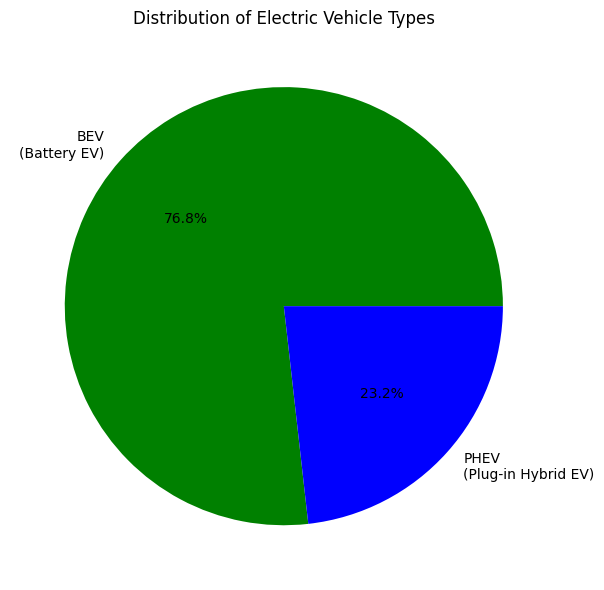

In [39]:
# BEV vs PHEV Distribution

fig, ax = plt.subplots(figsize=(8, 6))

ev_counts = df['Electric Vehicle Type'].value_counts()
colors = ['green', 'blue']
ax.pie(ev_counts, labels=['BEV\n(Battery EV)', 'PHEV\n(Plug-in Hybrid EV)'],
       autopct='%1.1f%%', colors=colors)
ax.set_title('Distribution of Electric Vehicle Types')
plt.tight_layout()
plt.show()

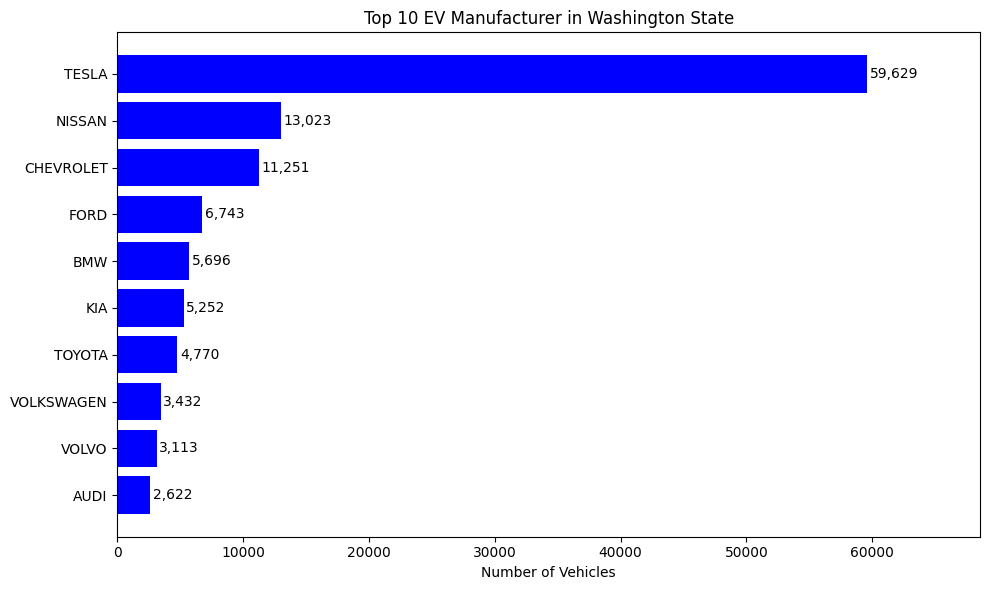

In [43]:
# Top 10 EV Manufacturer

fig, ax = plt.subplots(figsize=(10, 6))

top10_maker = df['Make'].value_counts().head(10)
bars = ax.barh(top10_maker.index[::-1], top10_maker.values[::-1], color='blue')

# Label nilai
for bar, val in zip(bars, top10_maker.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center')

ax.set_title('Top 10 EV Manufacturer in Washington State')
ax.set_xlabel('Number of Vehicles')
ax.set_xlim(0, top10_maker.max() * 1.15)
plt.tight_layout()
plt.show()

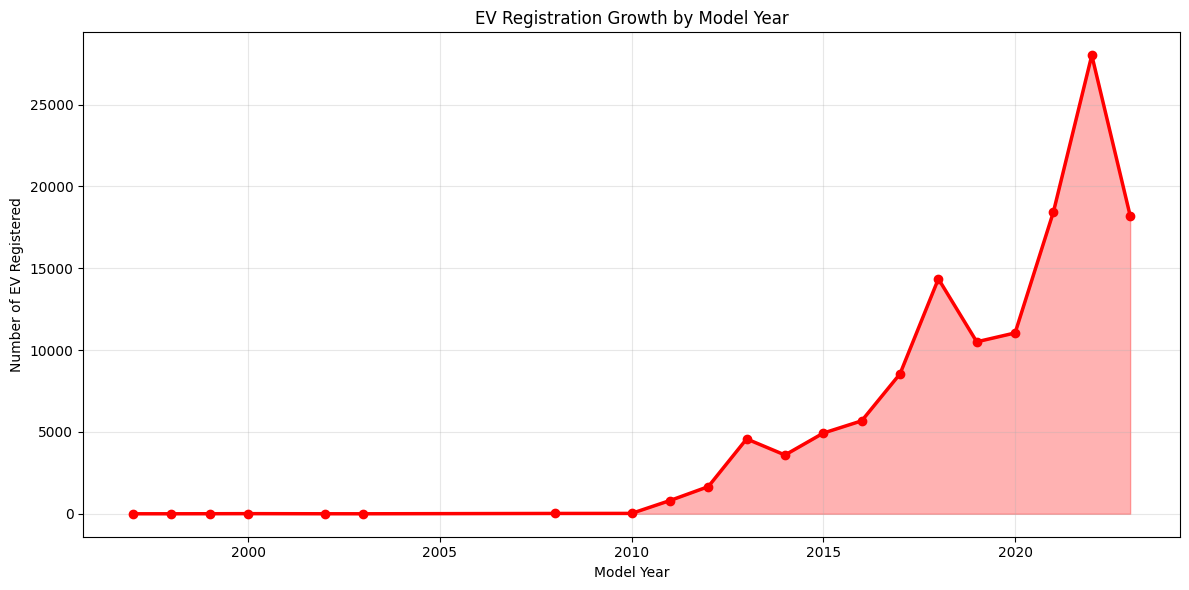

In [46]:
# EV Growth per Model Year

fig, ax = plt.subplots(figsize=(12, 6))

growth = df['Model Year'].value_counts().sort_index()
ax.plot(growth.index, growth.values, marker='o', linewidth=2.5, 
        color='red')
ax.fill_between(growth.index, growth.values, alpha=0.3, color='red')

ax.set_title('EV Registration Growth by Model Year')
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of EV Registered')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

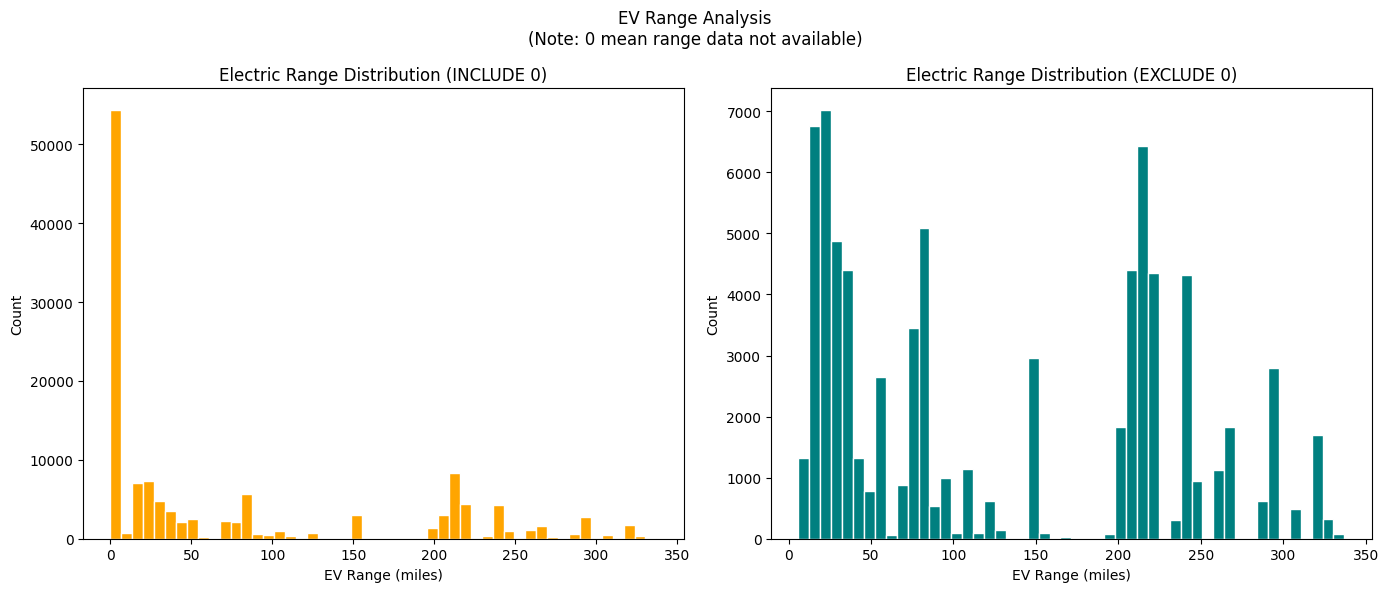

EV dengan range = 0: 53446 (41.0%)
EV dengan range > 0: 76997 (59.0%)


In [47]:
# EV range distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Termasuk yang 0
axes[0].hist(df['Electric Range'], bins=50, color='orange', edgecolor='white')
axes[0].set_title('Electric Range Distribution (INCLUDE 0)')
axes[0].set_xlabel('EV Range (miles)')
axes[0].set_ylabel('Count')

# Kecuali 0 (Unknown)
df_range = df[df['Electric Range'] > 0]
axes[1].hist(df_range['Electric Range'], bins=50, color='teal', edgecolor='white')
axes[1].set_title('Electric Range Distribution (EXCLUDE 0)')
axes[1].set_xlabel('EV Range (miles)')
axes[1].set_ylabel('Count')

plt.suptitle('EV Range Analysis\n(Note: 0 mean range data not available)')
plt.tight_layout()
plt.show()

print(f'EV dengan range = 0: {(df["Electric Range"] == 0).sum()} ({(df["Electric Range"] == 0).mean()*100:.1f}%)')
print(f'EV dengan range > 0: {(df["Electric Range"] > 0).sum()} ({(df["Electric Range"] > 0).mean()*100:.1f}%)')

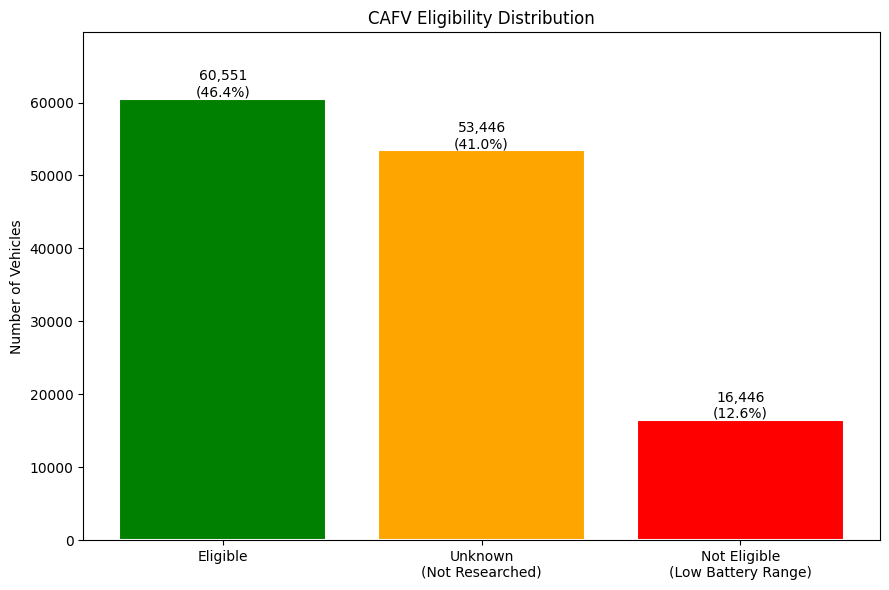

In [48]:
# CAFV Eligibility

fig, ax = plt.subplots(figsize=(9, 6))

cafv = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
labels = ['Eligible', 'Unknown\n(Not Researched)', 'Not Eligible\n(Low Battery Range)']
colors = ['green', 'orange', 'red']

bars = ax.bar(labels, cafv.values, color=colors, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, cafv.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}\n({val/len(df)*100:.1f}%)', 
            ha='center')

ax.set_title('CAFV Eligibility Distribution')
ax.set_ylabel('Number of Vehicles')
ax.set_ylim(0, cafv.max() * 1.15)
plt.tight_layout()
plt.show()

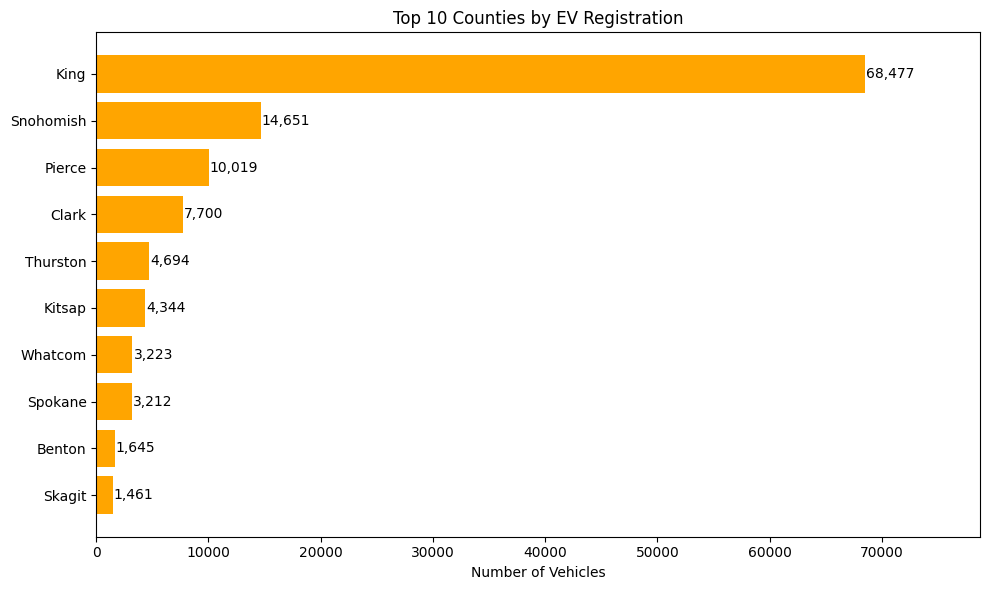

In [49]:
# Top 10 Counties by EV Registration

fig, ax = plt.subplots(figsize=(10, 6))

top10_county = df['County'].value_counts().head(10)
bars = ax.barh(top10_county.index[::-1], top10_county.values[::-1], color='orange')

for bar, val in zip(bars, top10_county.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center')

ax.set_title('Top 10 Counties by EV Registration')
ax.set_xlabel('Number of Vehicles')
ax.set_xlim(0, top10_county.max() * 1.15)
plt.tight_layout()
plt.show()

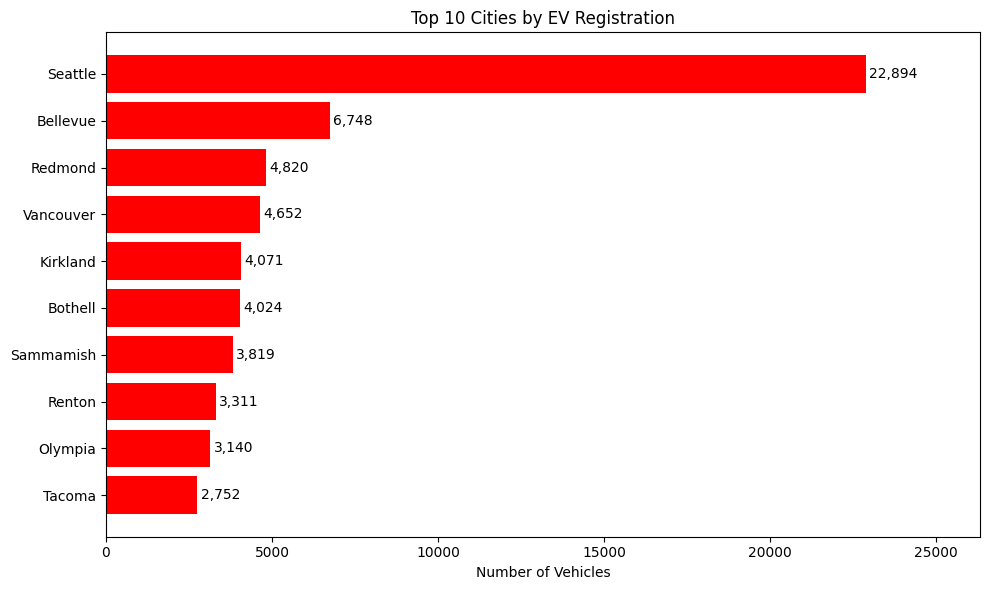

In [50]:
# Top 10 Cities by EV Registration

fig, ax = plt.subplots(figsize=(10, 6))

top10_city = df['City'].value_counts().head(10)
bars = ax.barh(top10_city.index[::-1], top10_city.values[::-1], color='red')

for bar, val in zip(bars, top10_city.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center')

ax.set_title('Top 10 Cities by EV Registration')
ax.set_xlabel('Number of Vehicles')
ax.set_xlim(0, top10_city.max() * 1.15)
plt.tight_layout()
plt.show()

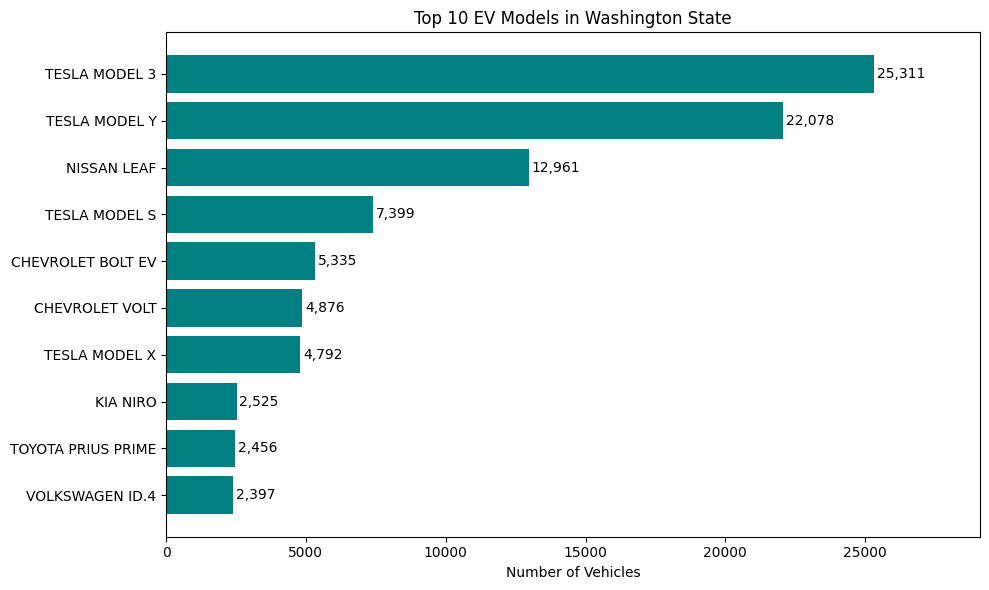

In [51]:
# Top 10 EV Models in Washington State

fig, ax = plt.subplots(figsize=(10, 6))

top10_model = df.groupby(['Make', 'Model']).size().reset_index(name='count')
top10_model = top10_model.sort_values('count', ascending=False).head(10)
top10_model['label'] = top10_model['Make'] + ' ' + top10_model['Model']

bars = ax.barh(top10_model['label'].values[::-1], 
               top10_model['count'].values[::-1], color='teal')

for bar, val in zip(bars, top10_model['count'].values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center')

ax.set_title('Top 10 EV Models in Washington State')
ax.set_xlabel('Number of Vehicles')
ax.set_xlim(0, top10_model['count'].max() * 1.15)
plt.tight_layout()
plt.show()

Analisis Chart

a. Chart 1 — BEV vs PHEV Distribution :
- Washintong State didominasi oleh kendaraan battery EV (full electric(BEV)) dengan persentase sebesar 76.8% dibandingkan dengan Plug-in EV 23.2%. Hasil ini menunjukkan salah satu alasan konsumen WA lebih memilih kendaraan zero-emission penuh atau ada alasan lainnya.

b. Chart 2 — Top 10 EV Manufacturer :
- Berdasarkan chart Tesla mendominasi sangat jauh dengan 59.629 unit (45.7%), hampir 5x lipat dari Nissan yang berada di posisi ke-2 dengan jumlah 13.023 unit, Ini menunjukkan Tesla adalah salah satu brand manufaturer yang booming di seluruh USA jadi tidak salah kalau disebut sebagai benchmark untuk EV di America.

c. Chart 3 — EV Growth per Model Year:
- Adopsi EV terutama di America sangat lambat hingga 2010, disini mulai naik pembelian EV dengan brand Tesla lalu mulai naik signifikan. Puncaknya di tahun 2022 dengan 27.000+ registrasi asumsi terhadap pembelian terhadap model baru dari Tesla Cybertruck, lalu penurunan di 2023 kemungkinan karena dataset diambil di tengah tahun, bukan karena penurunan adopsi.

d. Chart 4 — Electric Vehicle Range:
- Berdasarkan dataset 41.6% kendaraan tidak memiliki jarak yang diberikan atau range/jarak = 0 (data tidak tersedia), dan dari kendaraan yang memiliki data range distribusi terbagi 2 kelompok yaitu kendaraan jarak pendek (PHEV, 10-50 miles) dan jarak panjang (BEV, 200-300+ miles).

e. Chart 5 — CAFV Eligibility:
- Berdasarkan dataset hanya 46.4% EV yang eligible untuk insentif pemerintah USA dan yang mengkhawatirkan adalah 41% masih berstatus Unknown karena battery range belum diteliti / dites ini bisa menjadi peluang bagi tim sales dari brand-brand lain untuk mendorong lebih banyak kendaraan masuk program insentif.

f. Chart 6 — Top 10 Counties by EV Registration:
- Berdasarkan dataset King County sangat mendominasi dengan 68.477 unit (52.5% dari total) yang mana masuk akal karena King County adalah County dengan populasi terbesar di Washington State (-+ 2.26 juta) diikuti oleh Pierce County (-+ 960.000) dan Snohomish (-+ 890.000), berdasarkan registrasi EV King County hampir 5x lipat Snohomish di posisi 2 dan Pierce County di posisi 3. Menunjukkan adopsi EV lebih cepat berkembang di perkotaan yang ramai dan padat 

g. Chart 7 — Top 10 Cities by EV Registration:
- Berdasarkan dataset Seattle memimpin jauh dengan 22.894 unit, diikuti Bellevue 6.748 unit dan Redmond 4.820 unit, ini masuk akal karena ketiga kota tersebut berada di King County dan juga Kirkland di posisi 5 dan Vancouver yang berada di posisi 2 dari Clark County. Menunjukkan adopsi EV lebih cepat di perkotaan yang ramai dan padat

h. Chart 8 — Top 10 Models:
- Berdasarkan data ini asumsi benar bahwa Brand Manufacturer yang laku di USA adalah Tesla karena ada 4 Model EV Tesla yang menduduki posisi top 10, bahkan Tesla Model 3 adalah model terlaris dengan 25.311 unit, diikuti Tesla Model Y 22.078 unit dan Nissan LEAF adalah satu-satunya non-Tesla yang masuk top 3 dengan 12.961 unit.